<a href="https://colab.research.google.com/github/Muzzikon/WWML/blob/main/WWML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The first 3 weeks

In [ ]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Генерация данных

def generate_apartment():
    location = random.randint(1, 10)
    rooms = random.randint(1, 6)
    distance = round(random.uniform(0.5, 25), 2)
    floor = random.randint(1, 25)

    mean_area = 50  # Средняя площадь
    std_area = 20   # Стандартное отклонение площади
    S = round(np.random.normal(mean_area, std_area), 1)
    S = max(S, 10)  # Площадь не может быть меньше 10 м^2

    base_m2_price = 150000
    loc_coeff = 1.7 - (location / 10)
    dist_coeff = max(0.6, 1 - (distance / 50))
    final_m2_price = base_m2_price * loc_coeff * dist_coeff

    total_price = (int((S * final_m2_price) * random.uniform(0.95, 1.05)) // 10000) * 10000
    total_vis_price = str(total_price)[:-6] + '.' + str(total_price)[-6:-3] + '.' + str(total_price)[-4:-1]
    information = {
        "район": location,
        "площадь m^2": S,
        "кол-во комнат": rooms,
        "удаленность от центра (км)": distance,
        "этаж": floor,
        "цена": total_price}

    return information

def generate_data(n=1000):
    data = [generate_apartment() for _ in range(n)]
    return pd.DataFrame(data)

if __name__ == "__main__":
    data_set = generate_data()
    data_set.to_csv('dataset.csv', index=False)

In [ ]:
# Показ данных

data_set = generate_data(1000)  # Генерируем сразу 1000 записей
pd.set_option('display.expand_frame_repr', False)  # Запретить перенос строк
pd.set_option('display.max_columns', None)       # Показывать все столбцы

print (data_set)

     район  площадь m^2  кол-во комнат  удаленность от центра (км)  этаж      цена
0        4         32.2              2                       21.79    15   3930000
1        8         37.0              6                        2.04    16   4810000
2        7         10.0              3                        9.51    23   1260000
3        1         27.5              4                        1.14    23   6270000
4        5         33.4              4                       10.06     5   4570000
..     ...          ...            ...                         ...   ...       ...
995      4         20.3              6                        1.05     7   3730000
996      2        139.7              3                       23.10     8  18560000
997      5         57.0              5                        9.29    25   7980000
998      9         80.7              5                        5.65    20   8260000
999      9         45.4              1                       12.78     6   4050000

[10

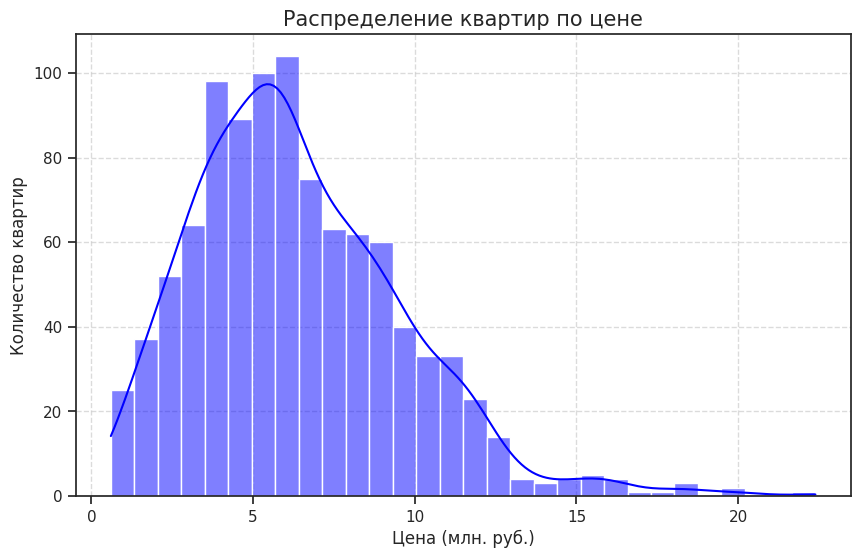

In [ ]:
# Гистограмма

sns.set_theme(style="ticks", palette="pastel")
plt.figure(figsize=(10,6))
prices_in_millions = data_set["цена"] / 1_000_000
sns.histplot(prices_in_millions, bins=30, kde=True, color='blue')
plt.title("Распределение квартир по цене",fontsize=15)
plt.xlabel("Цена (млн. руб.)", fontsize=12)
plt.ylabel("Количество квартир", fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

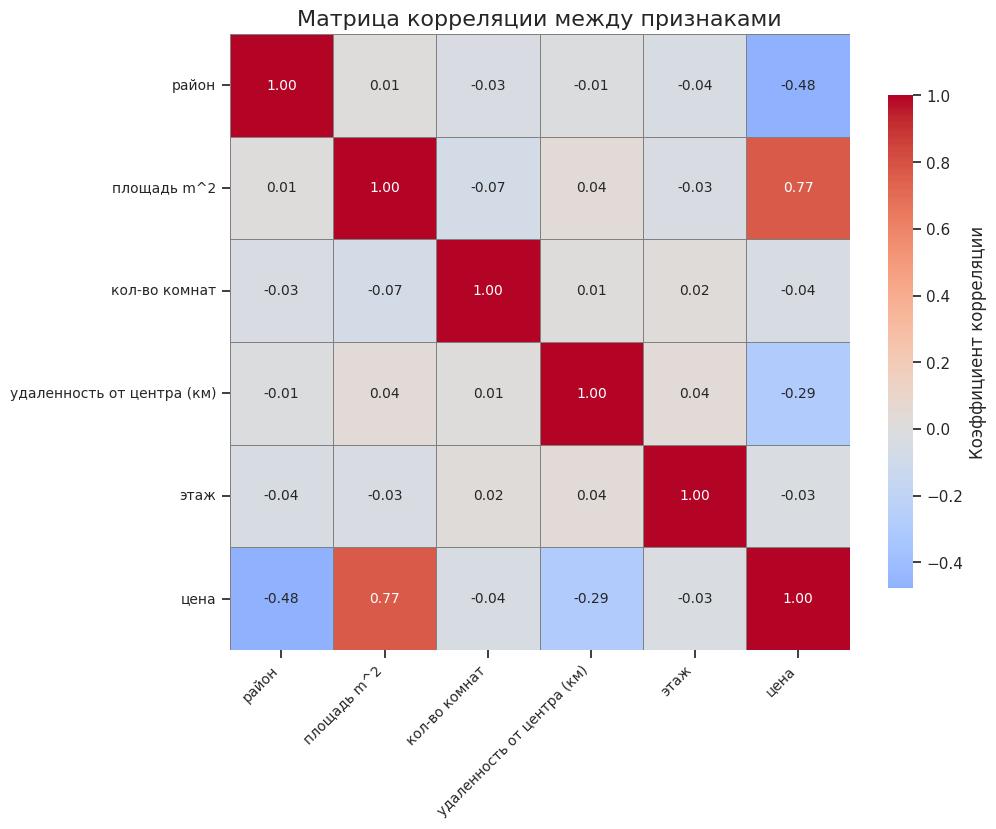

In [ ]:
# Матрица корреляции

correlation_matrix = data_set.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции"},
            fmt='.2f',
            annot_kws={'size': 10},

            linewidths=0.5,
            linecolor='gray')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.title("Матрица корреляции между признаками", fontsize=16)
plt.show()

# The second 3 weeks

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

In [ ]:
# Обучение модели

data_set = pd.read_csv('dataset.csv')

# Разделим данные на признаки и целевую переменную
X = data_set.drop(columns=["цена"])  # Признаки
y = data_set["цена"]  # Целевая переменная

# Разделим на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучаем модель линейной регрессии
model = LinearRegression()
model.fit(X_train, y_train)

# Предсказания на тестовых данных
y_pred = model.predict(X_test)

# Оценка качества модели
mae = mean_absolute_error(y_test, y_pred)  # Средняя абсолютная ошибка
r2 = r2_score(y_test, y_pred)  # Коэффициент детерминации

print(f"MAE: {mae}")
print(f"R2: {r2}")

# Сохраняем модель
joblib.dump(model, "price_prediction_model.pkl")

MAE: 569406.4547856284
R2: 0.942098389429856


['price_prediction_model.pkl']

In [ ]:
# Запуск в приложении
import streamlit as st

# Загружаем обученную модель
model = joblib.load(r"D:\WWML\price_prediction_model.pkl")

st.title("Оценка стоимости квартиры")

# Ввод данных пользователем
location = st.number_input("Район (1-10)", min_value=1, max_value=10, value=5)
area = st.number_input("Площадь (м^2)", min_value=10, max_value=300, value=50)
rooms = st.number_input("Количество комнат", min_value=1, max_value=10, value=2)
distance = st.number_input("Удаленность от центра (км)", min_value=1, max_value=50, value=5)
floor = st.number_input("Этаж", min_value=1, max_value=25, value=1)

if st.button("Оценить"):
    input_data = pd.DataFrame([{
        "район": location,
        "площадь m^2": area,
        "кол-во комнат": rooms,
        "удаленность от центра (км)": distance,
        "этаж": floor
    }])

    predicted_price = model.predict(input_data)[0]

    st.write("Введенные данные:")
    st.dataframe(input_data)

    st.success(f"Предсказанная стоимость квартиры: {predicted_price:,.2f} рублей")